In [1]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. Load your data
# Thank you ChatGPT o4-mini-high for help with this analysis

filename="speed_dist_data_20231228.csv"
df = pd.read_csv(filename)

In [2]:
# 2. Engineer defender‐density: count of defenders within 5 yards, per frame
df['n_def_5yd'] = (
    df
    .groupby(['gameId', 'playId', 'frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d < 5).sum())
)

In [3]:
# 3. Filter to the ~2‐yard window
df_2yd = df[
    (df['toPlayerDistanceToBallCarrier'] >= 1.5) &
    (df['toPlayerDistanceToBallCarrier'] <= 2.5)
].copy()

# 4. Fit OLS: speed ~ proximity + defender density
model = smf.ols(
    'ballCarrierSpeed ~ toPlayerDistanceToBallCarrier + n_def_5yd',
    data=df_2yd
).fit()

# 5. Inspect results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                 4.996e+04
Date:                Mon, 28 Apr 2025   Prob (F-statistic):               0.00
Time:                        14:18:32   Log-Likelihood:            -6.8497e+05
No. Observations:              325787   AIC:                         1.370e+06
Df Residuals:                  325784   BIC:                         1.370e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [5]:

# 4. Fit OLS with additional covariates and fixed effects

formula = (
  'ballCarrierSpeed ~ '
  'toPlayerDistanceToBallCarrier + I(toPlayerDistanceToBallCarrier**2) + '
  'n_def_5yd + frameId + '
  'toPlayerAction_tackle + toPlayerAction_assist + '
  'toPlayerAction_forcedFumble + toPlayerAction_missedTackle + '
  'C(gameId)'
)
model = smf.ols(formula, data=df_2yd).fit()

# 5. View the results
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.257
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     786.7
Date:                Mon, 28 Apr 2025   Prob (F-statistic):               0.00
Time:                        14:32:16   Log-Likelihood:            -6.8020e+05
No. Observations:              325787   AIC:                         1.361e+06
Df Residuals:                  325643   BIC:                         1.362e+06
Df Model:                         143                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [6]:
formula = (
    'ballCarrierSpeed ~ '
    'toPlayerDistanceToBallCarrier + '
    'I(toPlayerDistanceToBallCarrier**2) + '
    'n_def_5yd + '
    'frameId + '
    'toPlayerAction_tackle + '
    'toPlayerAction_assist + '
    'toPlayerAction_forcedFumble + '
    'toPlayerAction_missedTackle + '
    'C(gameId)'
)

# 3a. Fit with clustered SEs directly
model_cluster = smf.ols(formula, data=df_2yd).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_2yd['playId']}
)

print(model_cluster.summary())


                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.257
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     84.97
Date:                Mon, 28 Apr 2025   Prob (F-statistic):               0.00
Time:                        14:35:17   Log-Likelihood:            -6.8020e+05
No. Observations:              325787   AIC:                         1.361e+06
Df Residuals:                  325643   BIC:                         1.362e+06
Df Model:                         143                                         
Covariance Type:              cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [8]:
# Moving to a mixed effects model, thanks ChatGPT for the help

import pandas as pd
import statsmodels.api as sm

# 1. Load your data

filename="speed_dist_data_20231228.csv"
df = pd.read_csv(filename)

# removed the football which has a PlayerNflId of zero
df = df[df['toPlayerNflId'] != 0]

# 2. Re-engineer defender-density if you haven’t already
df['n_def_5yd'] = (
    df
    .groupby(['gameId', 'playId', 'frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d < 5).sum())
)

# 3. Filter to the ∼2-yard band
df_2yd = df[
    (df.toPlayerDistanceToBallCarrier >= 1.5) &
    (df.toPlayerDistanceToBallCarrier <= 2.5)
].copy()

# 4. Specify the mixed‐effects formula
#    Fixed effects: distance, distance², density, time, contact flags, game as fixed
#    Random effect: intercept by playId
formula = (
    'ballCarrierSpeed ~ '
    'toPlayerDistanceToBallCarrier + '
    'I(toPlayerDistanceToBallCarrier**2) + '
    'n_def_5yd + '
    'frameId + '
    'toPlayerAction_tackle + '
    'toPlayerAction_assist + '
    'toPlayerAction_forcedFumble + '
    'toPlayerAction_missedTackle + '
    'C(gameId)'
)

# 5. Build and fit the model
#    re_formula='1' means a random intercept only
md = sm.MixedLM.from_formula(
    formula,
    groups='playId',
    re_formula='1',
    data=df_2yd
)
mdf = md.fit(reml=False)  # reml=False for ML estimation
print(mdf.summary())


                      Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       ballCarrierSpeed
No. Observations:         303838        Method:                   ML              
No. Groups:               3952          Scale:                    2.8203          
Min. group size:          1             Log-Likelihood:           -594922.1047    
Max. group size:          884           Converged:                Yes             
Mean group size:          76.9                                                    
----------------------------------------------------------------------------------
                                      Coef.  Std.Err.    z     P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                              4.265    0.172   24.827 0.000  3.929  4.602
C(gameId)[T.2022091100]                0.663    0.069    9.601 0.000  0.528  0.799
C(gameId)[T.2022091101]    

In [10]:
import pandas as pd
import statsmodels.api as sm

# 1. Reload & prep (if you need to start fresh)
filename="speed_dist_data_20231228.csv"
df = pd.read_csv(filename)

df = df[df['toPlayerNflId'] != 0]
df['n_def_5yd'] = (
    df
    .groupby(['gameId','playId','frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d<5).sum())
)
df_2yd = df[
    (df.toPlayerDistanceToBallCarrier >= 1.5)&
    (df.toPlayerDistanceToBallCarrier <= 2.5)
].copy()

# 2. Ensure playType is categorical
df_2yd['playType'] = df_2yd['playType'].astype('category')

# 3. Specify a mixed‐effects model with cross‐level interactions
formula = (
    'ballCarrierSpeed ~ '
    'toPlayerDistanceToBallCarrier * C(playType) + '
    'I(toPlayerDistanceToBallCarrier**2) * C(playType) + '
    'n_def_5yd + frameId + '
    'toPlayerAction_tackle + toPlayerAction_assist + '
    'toPlayerAction_forcedFumble + toPlayerAction_missedTackle + '
    'C(gameId)'
)

md_int = sm.MixedLM.from_formula(
    formula,
    groups='playId',
    re_formula='1',
    data=df_2yd
)
mdf_int = md_int.fit(reml=False)
print(mdf_int.summary())


MemoryError: Unable to allocate 97.0 MiB for an array with shape (2, 6358548) and data type float64

In [11]:
import pandas as pd
import statsmodels.api as sm

filename = "speed_dist_data_20231228.csv"

# 1. Define only the columns you actually need
usecols = [
    'gameId','playId','frameId','playType',
    'ballCarrierSpeed','toPlayerNflId','toPlayerDistanceToBallCarrier',
    'toPlayerAction_tackle','toPlayerAction_assist',
    'toPlayerAction_forcedFumble','toPlayerAction_missedTackle'
]

chunks = pd.read_csv(filename,
                     usecols=usecols,
                     chunksize=500_000,  # tune to your available RAM
                     dtype={
                       'playType':'category',
                       'toPlayerNflId':'int32',
                       'gameId':'category','playId':'category'
                     })

filtered = []
for chunk in chunks:
    # drop the football
    chunk = chunk[chunk.toPlayerNflId != 0]
    # restrict to the 2-yd band
    mask = (chunk.toPlayerDistanceToBallCarrier >= 1.5) & \
           (chunk.toPlayerDistanceToBallCarrier <= 2.5)
    filtered.append(chunk.loc[mask])
# concat only the ≈300 K rows you need
df_2yd = pd.concat(filtered, ignore_index=True)
del filtered, chunks

# 2. Engineer defender-density
df_2yd['n_def_5yd'] = (
    df_2yd
    .groupby(['gameId','playId','frameId'])
    ['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d<5).sum())
)

# 3. Build the mixed‐effects interaction model
formula = (
    'ballCarrierSpeed ~ '
    'toPlayerDistanceToBallCarrier * C(playType) + '
    'I(toPlayerDistanceToBallCarrier**2) * C(playType) + '
    'n_def_5yd + frameId + '
    'toPlayerAction_tackle + toPlayerAction_assist + '
    'toPlayerAction_forcedFumble + toPlayerAction_missedTackle + '
    'C(gameId)'
)

md_int = sm.MixedLM.from_formula(
    formula,
    groups='playId',
    re_formula='1',
    data=df_2yd
)
mdf_int = md_int.fit(reml=False)
print(mdf_int.summary())


                                     Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 ballCarrierSpeed
No. Observations:                  303838                  Method:                             ML              
No. Groups:                        3952                    Scale:                              3.2802          
Min. group size:                   1                       Log-Likelihood:                     -618048.5684    
Max. group size:                   884                     Converged:                          Yes             
Mean group size:                   76.9                                                                        
---------------------------------------------------------------------------------------------------------------
                                                                   Coef.  Std.Err.    z     P>|z| [0.025 0.975]
-----------------------------

C:\Users\charl\AppData\Local\Temp\ipykernel_21288\4079099121.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_speed_dist = df_2yd.groupby('dist_bin')['ballCarrierSpeed'].mean().values


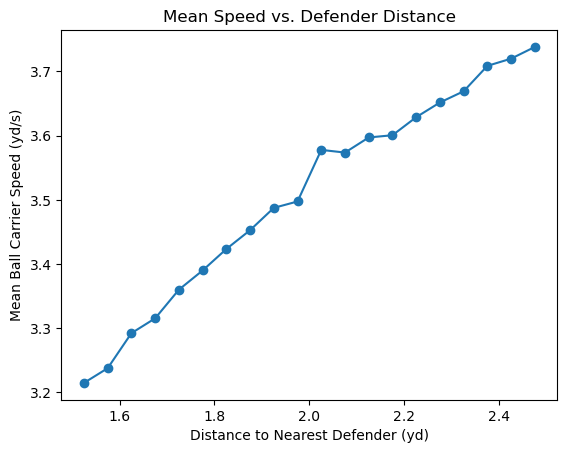

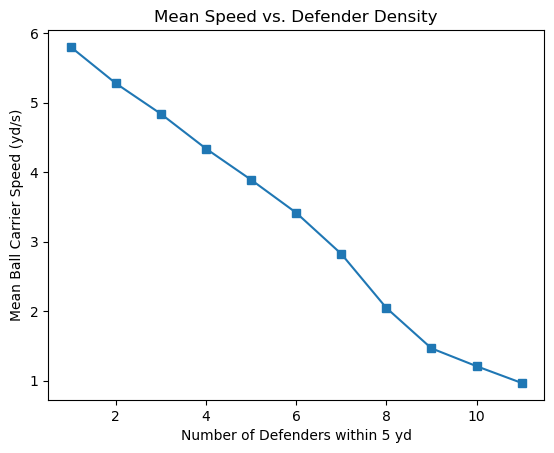

C:\Users\charl\AppData\Local\Temp\ipykernel_21288\4079099121.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_bin = subset.groupby('dist_bin')['ballCarrierSpeed'].mean().values


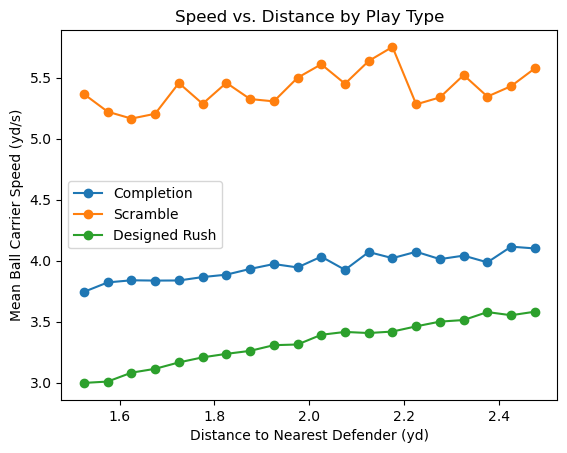

ModuleNotFoundError: No module named 'ace_tools'

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename="speed_dist_data_20231228.csv"
df = pd.read_csv(filename)

df = df[df['toPlayerNflId'] != 0]
df['n_def_5yd'] = (
    df
    .groupby(['gameId','playId','frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d<5).sum())
)
df_2yd = df[
    (df.toPlayerDistanceToBallCarrier >= 1.5)&
    (df.toPlayerDistanceToBallCarrier <= 2.5)
].copy()

# 1. Mean speed by defender distance (binned)
bins = np.linspace(1.5, 2.5, 21)
df_2yd['dist_bin'] = pd.cut(df_2yd['toPlayerDistanceToBallCarrier'], bins)
mean_speed_dist = df_2yd.groupby('dist_bin')['ballCarrierSpeed'].mean().values
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure()
plt.plot(bin_centers, mean_speed_dist, marker='o')
plt.xlabel('Distance to Nearest Defender (yd)')
plt.ylabel('Mean Ball Carrier Speed (yd/s)')
plt.title('Mean Speed vs. Defender Distance')
plt.show()

# 2. Mean speed by defender density
mean_speed_density = df_2yd.groupby('n_def_5yd')['ballCarrierSpeed'].mean().values
density_levels = df_2yd['n_def_5yd'].unique()
density_levels.sort()

plt.figure()
plt.plot(density_levels, mean_speed_density, marker='s')
plt.xlabel('Number of Defenders within 5 yd')
plt.ylabel('Mean Ball Carrier Speed (yd/s)')
plt.title('Mean Speed vs. Defender Density')
plt.show()

# 3. Mean speed vs distance by playType
plt.figure()
for ptype in df_2yd['playType'].unique():
    subset = df_2yd[df_2yd['playType'] == ptype]
    mean_by_bin = subset.groupby('dist_bin')['ballCarrierSpeed'].mean().values
    plt.plot(bin_centers, mean_by_bin, marker='o', label=ptype)
plt.xlabel('Distance to Nearest Defender (yd)')
plt.ylabel('Mean Ball Carrier Speed (yd/s)')
plt.title('Speed vs. Distance by Play Type')
plt.legend()
plt.show()

# Save a summary DataFrame for review
summary_df = pd.DataFrame({
    'Distance (bin center)': bin_centers,
    'Mean Speed': mean_speed_dist
})
import ace_tools as tools; tools.display_dataframe_to_user(name="Distance vs. Speed Summary", dataframe=summary_df)
